## Setup

In [ ]:
import sys
from dotenv import load_dotenv
import os

load_dotenv()
sys.path.append(os.getenv("ROOT"))

In [3]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from silverfund.covariance_matrix import covariance_matrix_constructor
from silverfund.portfolios import mean_variance_efficient
from datetime import date

In [4]:
def cumulative_sum(returns):
    cum_sum = []
    current_sum = 0
    for r in returns:
        current_sum += r
        cum_sum.append(current_sum)
    return cum_sum

## Combine Parquets

files = [f'~/groups/grp_quant/data/daily_merged/mm_{i+1995}.parquet' for i in range(30)]

dfs = [pd.read_parquet(file) for file in files]

df_combined = pd.concat(dfs, ignore_index=True, sort=False)

df_combined.to_parquet("merged_output.parquet")

## Loading and Selecting

In [5]:
df_polars = pl.read_parquet('/home/boobus/projects/merged_output.parquet')

columns_to_drop = ['date', 'obsdate','enddate','cusip', 'ticker', 'issue_name',
                  'shrout_crsp','total_risk',
                   'ncusip_crsp','ticker_crsp','shrcd_crsp',
                   'exchcd_crsp','siccd_crsp','prc_crsp']
df_polars = df_polars.drop(columns_to_drop)

df_raw = df_polars.to_pandas()

In [ ]:
df_raw

,DataDate,permno,barrid,ret_crsp,retx_crsp,vol_crsp,price_barra,mktcap_barra,ret_barra,spec_ret,spec_risk,HistBeta,PredBeta
0,1995-02-13,27385.0,None,0.003906,0.003906,14800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1995-02-14,27385.0,None,0.000000,0.000000,1800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1995-02-15,27385.0,None,0.011673,0.011673,13900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1995-02-16,27385.0,None,-0.019231,-0.019231,31600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1995-02-17,27385.0,None,-0.011765,-0.011765,16600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22259558,2025-01-29,15857.0,USBDBE1,NaN,NaN,NaN,11.91,1.816510e+09,-0.010797,-0.02444,0.681237,1.442293,1.457090
22259559,2025-01-30,15857.0,USBDBE1,NaN,NaN,NaN,12.06,1.839388e+09,0.012594,-0.01399,0.679530,1.446697,1.454824
22259560,2025-01-31,15857.0,USBDBE1,NaN,NaN,NaN,11.57,1.764654e+09,-0.040630,-0.02808,0.681884,1.464617,1.491462
22259561,2025-02-03,15857.0,USBDBE1,NaN,NaN,NaN,11.86,1.808884e+09,0.025065,0.02827,0.678589,1.437362,1.494141


## Signal and Backtest

**Signal for BackTest**

## Supervised Learning

**Additional Features**

**Do not trade reversal after:**

When there is news, the price to revert to changes, and there will be no reversion

- Earnings report
- Dramatic price jump
- High volume spike

## Momentum

In [7]:
df_raw.head()

,DataDate,permno,barrid,ret_crsp,retx_crsp,vol_crsp,price_barra,mktcap_barra,ret_barra,spec_ret,spec_risk,HistBeta,PredBeta
0,1995-02-13,27385.0,None,0.003906,0.003906,14800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1995-02-14,27385.0,None,0.000000,0.000000,1800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1995-02-15,27385.0,None,0.011673,0.011673,13900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1995-02-16,27385.0,None,-0.019231,-0.019231,31600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1995-02-17,27385.0,None,-0.011765,-0.011765,16600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Signal X**

In [8]:
n = 252
skip = 22

df = df_raw.copy()

df['log_ret'] = np.log(1+df['ret_crsp'])
df['x'] = df.groupby('permno')['log_ret'].transform(
    lambda x: x.rolling(n).mean()
)
df['x'] = df.groupby('permno')['x'].shift(skip)

In [9]:
sdf = df.query('x == x')

In [10]:
sdf['bins'] = pd.qcut(sdf['x'], 10, labels=False)
ports = sdf.groupby(['DataDate', 'bins'])['ret_crsp'].mean().unstack()

/tmp/ipykernel_1644892/1959766566.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sdf['bins'] = pd.qcut(sdf['x'], 10, labels=False)


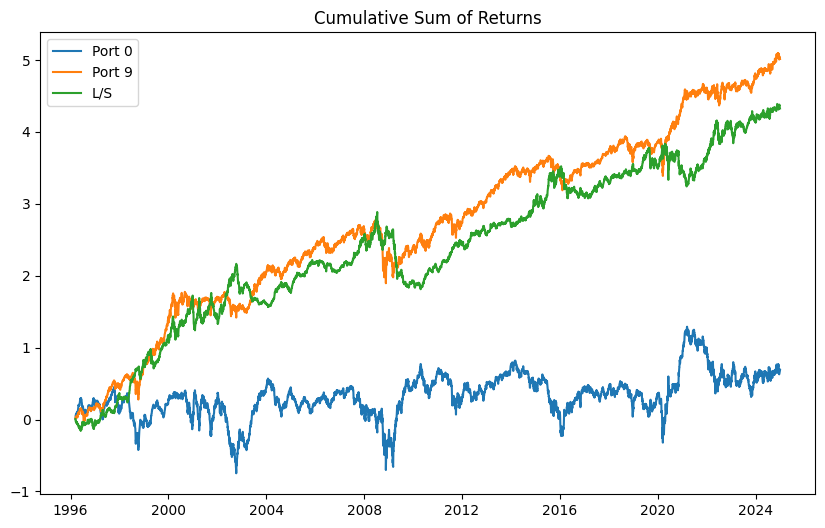

In [11]:
date_range = ports.index.get_level_values('DataDate')

plt.figure(figsize=(10, 6))
plt.title('Cumulative Sum of Returns')
plt.plot(date_range, cumulative_sum(ports[0]), label='Port 0')
plt.plot(date_range, cumulative_sum(ports[9]), label='Port 9')
plt.plot(date_range, cumulative_sum(ports[9] - ports[0]), label='L/S')
plt.legend()
plt.show()

**Z score**

In [12]:
x_mean = sdf.groupby('DataDate')['x'].mean().reset_index(name='x_mean')
sdf = sdf.merge(x_mean, on='DataDate', how="left")
x_std = sdf.groupby('DataDate')['x'].std().reset_index(name='x_std')
sdf = sdf.merge(x_std, on='DataDate', how='left')

In [13]:
sdf['z_score'] = (sdf['x'] - sdf['x_mean']) / sdf['x_std']
sdf

,DataDate,permno,barrid,ret_crsp,retx_crsp,vol_crsp,price_barra,mktcap_barra,ret_barra,spec_ret,spec_risk,HistBeta,PredBeta,log_ret,x,bins,x_mean,x_std,z_score
0,1996-03-13,80009.0,USAR4X1,0.036199,0.036199,96800.0,28.625,1.930470e+08,0.036199,0.02978,0.392997,1.091575,1.417850,0.035559,0.002813,9,7.883212e-04,0.001476,1.371564
1,1996-03-14,80009.0,USAR4X1,0.013100,0.013100,1920.0,29.000,1.955760e+08,0.013100,-0.00906,0.392056,1.095631,1.415751,0.013015,0.003036,9,7.911781e-04,0.001481,1.515513
2,1996-03-15,80009.0,USAR4X1,-0.021552,-0.021552,5000.0,28.375,1.913610e+08,-0.021552,-0.01767,0.391794,1.093108,1.400124,-0.021788,0.003169,9,7.786742e-04,0.001483,1.611631
3,1996-03-18,80009.0,USAR4X1,0.022026,0.022026,9600.0,29.000,1.955760e+08,0.022026,0.01059,0.391103,1.157848,1.412265,0.021787,0.003081,9,7.558409e-04,0.001477,1.574548
4,1996-03-19,80009.0,USAR4X1,0.000000,0.000000,86900.0,29.000,1.955760e+08,0.000000,-0.00366,0.390585,1.160622,1.396547,0.000000,0.003021,9,7.699516e-04,0.001474,1.527392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19382216,2025-01-29,15857.0,USBDBE1,NaN,NaN,NaN,11.910,1.816510e+09,-0.010797,-0.02444,0.681237,1.442293,1.457090,NaN,0.004011,9,2.784727e-05,0.001987,2.004909
19382217,2025-01-30,15857.0,USBDBE1,NaN,NaN,NaN,12.060,1.839388e+09,0.012594,-0.01399,0.679530,1.446697,1.454824,NaN,0.003928,9,1.947686e-05,0.001983,1.970860
19382218,2025-01-31,15857.0,USBDBE1,NaN,NaN,NaN,11.570,1.764654e+09,-0.040630,-0.02808,0.681884,1.464617,1.491462,NaN,0.003690,9,-4.480866e-05,0.001975,1.891452
19382219,2025-02-03,15857.0,USBDBE1,NaN,NaN,NaN,11.860,1.808884e+09,0.025065,0.02827,0.678589,1.437362,1.494141,NaN,0.003560,9,-6.805265e-05,0.001969,1.842145


In [14]:
IC = 0.05
sdf['alpha'] = IC*sdf['spec_risk']*sdf['z_score']
sdf.loc[:, ['DataDate', 'permno', 'ret_crsp', 'barrid', 'retx_crsp', 'x', 'z_score', 'alpha']]

,DataDate,permno,ret_crsp,barrid,retx_crsp,x,z_score,alpha
0,1996-03-13,80009.0,0.036199,USAR4X1,0.036199,0.002813,1.371564,0.026951
1,1996-03-14,80009.0,0.013100,USAR4X1,0.013100,0.003036,1.515513,0.029708
2,1996-03-15,80009.0,-0.021552,USAR4X1,-0.021552,0.003169,1.611631,0.031571
3,1996-03-18,80009.0,0.022026,USAR4X1,0.022026,0.003081,1.574548,0.030791
4,1996-03-19,80009.0,0.000000,USAR4X1,0.000000,0.003021,1.527392,0.029829
...,...,...,...,...,...,...,...,...
19382216,2025-01-29,15857.0,NaN,USBDBE1,NaN,0.004011,2.004909,0.068291
19382217,2025-01-30,15857.0,NaN,USBDBE1,NaN,0.003928,1.970860,0.066963
19382218,2025-01-31,15857.0,NaN,USBDBE1,NaN,0.003690,1.891452,0.064488
19382219,2025-02-03,15857.0,NaN,USBDBE1,NaN,0.003560,1.842145,0.062503


**Optimization**

In [15]:
from silverfund.records import Alpha

**Cut and Set Date Range**

In [16]:
##left off at ?? started 2024-10-10 and did 40 iters
## made it to 2024-12-06? make sure to double check in 2025_weights.parquet

cdf = sdf.query('DataDate > "2020-01-01"')
date_range = cdf['DataDate'].dt.date.unique()[::-1]
len(date_range)

1280

In [17]:
all_alphas = []
i = 0
for date_ in date_range:
    print(f'{i} : {date_}')
    all_alphas.append(Alpha(
        alphas=pl.DataFrame({
            'date': sdf.query('DataDate == @date_')['DataDate'].dt.date,
            'barrid': sdf.query('DataDate == @date_')['barrid'],
            'alpha': sdf.query('DataDate == @date_')['alpha']
        }))
    )
    i += 1

0 : 2025-02-04
1 : 2025-02-03
2 : 2025-01-31
3 : 2025-01-30
4 : 2025-01-29
5 : 2025-01-28
6 : 2025-01-27
7 : 2025-01-24
8 : 2025-01-23
9 : 2025-01-22
10 : 2025-01-21
11 : 2025-01-17
12 : 2025-01-16
13 : 2025-01-15
14 : 2025-01-14
15 : 2025-01-13
16 : 2025-01-10
17 : 2025-01-08
18 : 2025-01-07
19 : 2025-01-06
20 : 2025-01-03
21 : 2025-01-02
22 : 2024-12-31
23 : 2024-12-30
24 : 2024-12-27
25 : 2024-12-26
26 : 2024-12-24
27 : 2024-12-23
28 : 2024-12-20
29 : 2024-12-19
30 : 2024-12-18
31 : 2024-12-17
32 : 2024-12-16
33 : 2024-12-13
34 : 2024-12-12
35 : 2024-12-11
36 : 2024-12-10
37 : 2024-12-09
38 : 2024-12-06
39 : 2024-12-05
40 : 2024-12-04
41 : 2024-12-03
42 : 2024-12-02
43 : 2024-11-29
44 : 2024-11-27
45 : 2024-11-26
46 : 2024-11-25
47 : 2024-11-22
48 : 2024-11-21
49 : 2024-11-20
50 : 2024-11-19
51 : 2024-11-18
52 : 2024-11-15
53 : 2024-11-14
54 : 2024-11-13
55 : 2024-11-12
56 : 2024-11-11
57 : 2024-11-08
58 : 2024-11-07
59 : 2024-11-06
60 : 2024-11-05
61 : 2024-11-04
62 : 2024-11-01
63

all_alphas = [Alpha(
    alphas=pl.DataFrame({
        'date': sdf.query('DataDate == @date_')['DataDate'].dt.date,
        'barrid': sdf.query('DataDate == @date_')['barrid'],
        'alpha': sdf.query('DataDate == @date_')['alpha']
    })
) for date_ in date_range]

In [18]:
all_barrids = [sdf.query('DataDate == @date_').sort_values(by='barrid')['barrid'].unique() for date_ in date_range]



all_weights = [mean_variance_efficient(
    period=date_range[i],
    barrids=all_barrids[i],
    alphas=all_alphas[i],
    constraints=[]
) for i in range(len(date_range))]

In [ ]:
all_weights = []
i = 0
for i in range(len(date_range)):
    all_weights.append(mean_variance_efficient(
        period=date_range[i],
        barrids=all_barrids[i],
        alphas=all_alphas[i],
        constraints=[]
    ))
    print(f'{i} : {date_range[i]}')
    if (i+1)%5 == 0:
        print("**Saved File**")
        w = pl.concat(all_weights, how="vertical")
        w.write_parquet("2025_weights.parquet")


w = pl.concat(all_weights, how="vertical")
w.write_parquet("2025_weights.parquet")

0 : 2025-02-04
1 : 2025-02-03
2 : 2025-01-31
3 : 2025-01-30
4 : 2025-01-29
**Saved File**
5 : 2025-01-28
6 : 2025-01-27
7 : 2025-01-24
8 : 2025-01-23
9 : 2025-01-22
**Saved File**
10 : 2025-01-21
11 : 2025-01-17
12 : 2025-01-16
13 : 2025-01-15
14 : 2025-01-14
**Saved File**
15 : 2025-01-13
16 : 2025-01-10
17 : 2025-01-08
18 : 2025-01-07
19 : 2025-01-06
**Saved File**
20 : 2025-01-03
21 : 2025-01-02


In [37]:
w = pl.concat(all_weights, how="vertical")
w.write_parquet("2025_weights.parquet")